# 🛩️ 터보팬 엔진이 언제 고장날까? — AI로 잔여수명(RUL) 예측하기

**NASA C-MAPSS 터보팬 엔진 열화 시뮬레이션 데이터**를 활용하여  
RandomForest / XGBoost / RNN / LSTM 4가지 모델의 **잔여수명(RUL)** 예측 성능을 비교합니다.

---

### 🎯 실습 목표
- 실제 산업용 시계열 데이터를 다뤄본다
- 전통 ML vs 딥러닝의 시계열 예측 성능을 직접 비교한다
- 예측 결과를 바탕으로 "이 엔진 지금 교체해야 할까?" 판단하는 시스템을 만들어본다

### 📖 배경 지식
| 용어 | 설명 |
|------|------|
| RUL (Remaining Useful Life) | 장비가 고장나기까지 남은 사이클 수 |
| C-MAPSS | NASA에서 공개한 터보팬 엔진 열화 시뮬레이션 |
| PHM (Prognostics & Health Management) | 장비 건강 상태를 예측하고 관리하는 분야 |

> 💡 비행기 엔진 하나의 가격은 수십억 원입니다.  
> 너무 일찍 교체하면 돈 낭비, 너무 늦으면 사고 발생!  
> **정확한 RUL 예측 = 생명 + 비용 동시에 지키기** 🛡️

In [ ]:
# ⚡ 패키지 설치 (Colab 전용)
!pip install xgboost -q

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
# 시각화 스타일
plt.rcParams['figure.facecolor'] = '#0e1117'
plt.rcParams['axes.facecolor'] = '#0e1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Device: {DEVICE}")
print("✅ 모든 라이브러리 로드 완료!")

Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
🖥️ Device: cuda
✅ 모든 라이브러리 로드 완료!


---
## 1️⃣ NASA C-MAPSS 데이터 로드

이 데이터셋에는 **100대의 터보팬 엔진**이 있고,  
각 엔진은 정상 상태에서 시작하여 **점점 열화되다가 고장**납니다.

- 21개 센서 측정값 (온도, 압력, 회전수 등)
- 3개 운전 조건 (고도, 마하수, 스로틀)
- 우리의 목표: **각 시점에서 엔진이 몇 사이클 후에 고장날지 예측!**

In [7]:
# NASA C-MAPSS 데이터 다운로드 (GitHub 미러)
import urllib.request
import os

BASE_URL = "https://raw.githubusercontent.com/mapr-demos/predictive-maintenance/master/notebooks/jupyter/Dataset/CMAPSSData"

files_to_download = ['train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt']

for fname in files_to_download:
    if not os.path.exists(fname):
        print(f"📥 {fname} 다운로드 중...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", fname)

print("✅ 모든 데이터 다운로드 완료!")
print(f"📂 파일 목록: {[f for f in os.listdir('.') if 'FD001' in f]}")

✅ 모든 데이터 다운로드 완료!
📂 파일 목록: ['RUL_FD001.txt', 'train_FD001.txt', 'test_FD001.txt']


In [8]:
# 컬럼 이름 정의
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

# 학습 데이터 로드
train_df = pd.read_csv('train_FD001.txt', sep='\\s+', header=None, names=columns)

# 테스트 데이터 로드
test_df = pd.read_csv('test_FD001.txt', sep='\\s+', header=None, names=columns)

# 테스트 RUL 정답
rul_df = pd.read_csv('RUL_FD001.txt', sep='\\s+', header=None, names=['RUL'])

print(f"🔧 학습 엔진 수: {train_df['engine_id'].nunique()}대")
print(f"📊 학습 데이터: {train_df.shape[0]:,}행 × {train_df.shape[1]}열")
print(f"🧪 테스트 엔진 수: {test_df['engine_id'].nunique()}대")
print(f"\n📋 컬럼 목록:")
print(train_df.columns.tolist())

🔧 학습 엔진 수: 100대
📊 학습 데이터: 20,631행 × 26열
🧪 테스트 엔진 수: 100대

📋 컬럼 목록:
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [9]:
# ⭐ RUL 라벨 생성
# 각 엔진의 마지막 사이클 = 고장 시점
# RUL = 마지막 사이클 - 현재 사이클

max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis=1, inplace=True)

# RUL 상한 클리핑 (125 이상은 큰 의미 없음 — 초기에는 "아직 멀었다" 정도)
RUL_CAP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

print("✅ RUL 라벨 생성 완료!")
print(f"\nRUL 분포:")
print(train_df['RUL'].describe())

# 엔진 1대 예시
engine1 = train_df[train_df['engine_id'] == 1]
print(f"\n🔍 엔진 #1: 총 {len(engine1)} 사이클 운행 후 고장")

✅ RUL 라벨 생성 완료!

RUL 분포:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

🔍 엔진 #1: 총 192 사이클 운행 후 고장


---
## 2️⃣ 탐색적 데이터 분석 (EDA)

엔진이 고장에 가까워질수록 센서 값이 어떻게 변하는지 살펴봅시다!

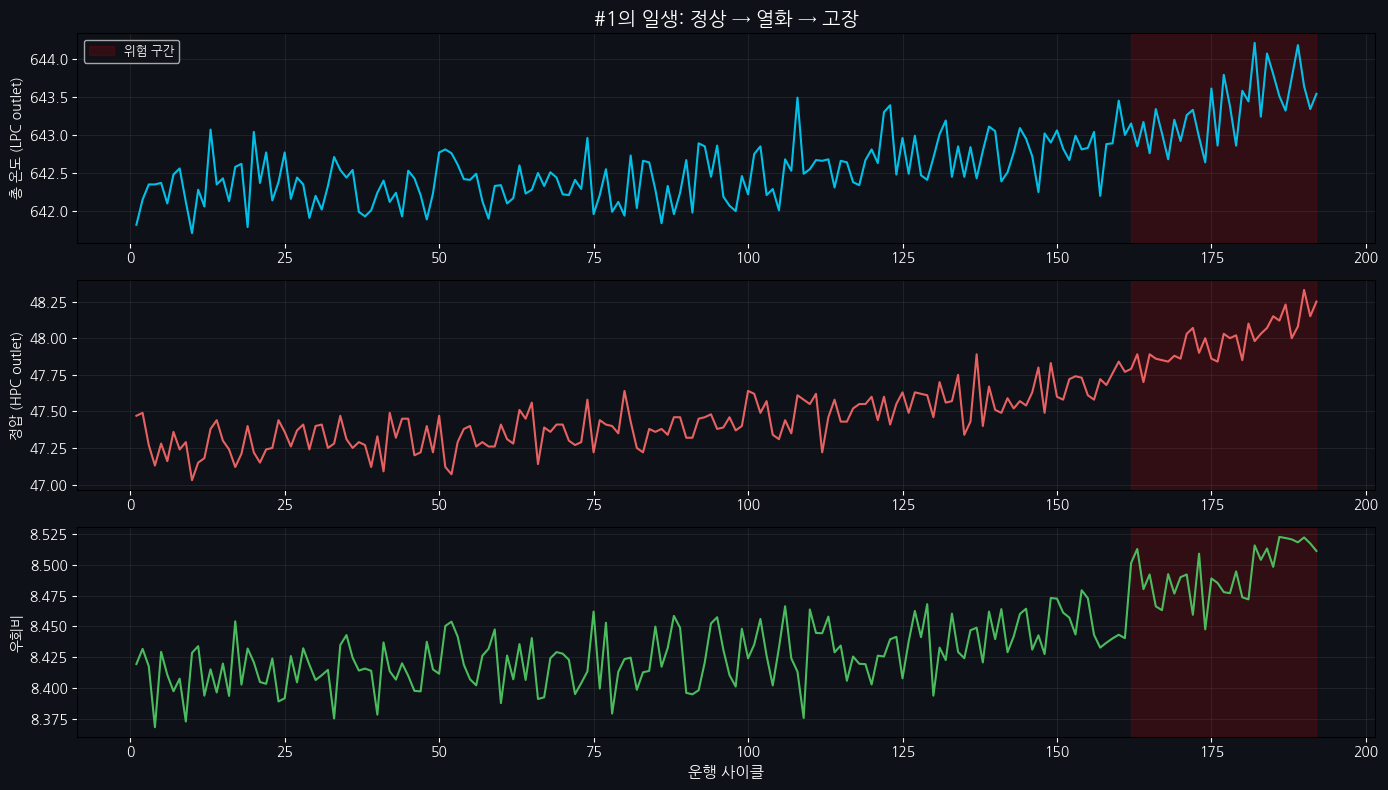

💡 빨간 영역이 '위험 구간'입니다. 센서 값이 급변하는 것이 보이나요?


In [11]:
# 🔥 엔진 한 대의 일생 — 건강 → 고장까지

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

engine_sample = train_df[train_df['engine_id'] == 1]

sensors_to_show = ['sensor_2', 'sensor_11', 'sensor_15']
sensor_labels = ['총 온도 (LPC outlet)', '정압 (HPC outlet)', '우회비']
colors = ['#00d4ff', '#ff6b6b', '#51cf66']

for i, (sensor, label, color) in enumerate(zip(sensors_to_show, sensor_labels, colors)):
    axes[i].plot(engine_sample['cycle'], engine_sample[sensor],
                 color=color, linewidth=1.5, alpha=0.9)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].grid(True, alpha=0.1)

    # 위험 구간 표시 (마지막 30 사이클)
    danger_start = engine_sample['cycle'].max() - 30
    axes[i].axvspan(danger_start, engine_sample['cycle'].max(),
                    color='red', alpha=0.15, label='위험 구간')

axes[0].set_title('#1의 일생: 정상 → 열화 → 고장', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('운행 사이클', fontsize=11)
axes[0].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 빨간 영역이 '위험 구간'입니다. 센서 값이 급변하는 것이 보이나요?")

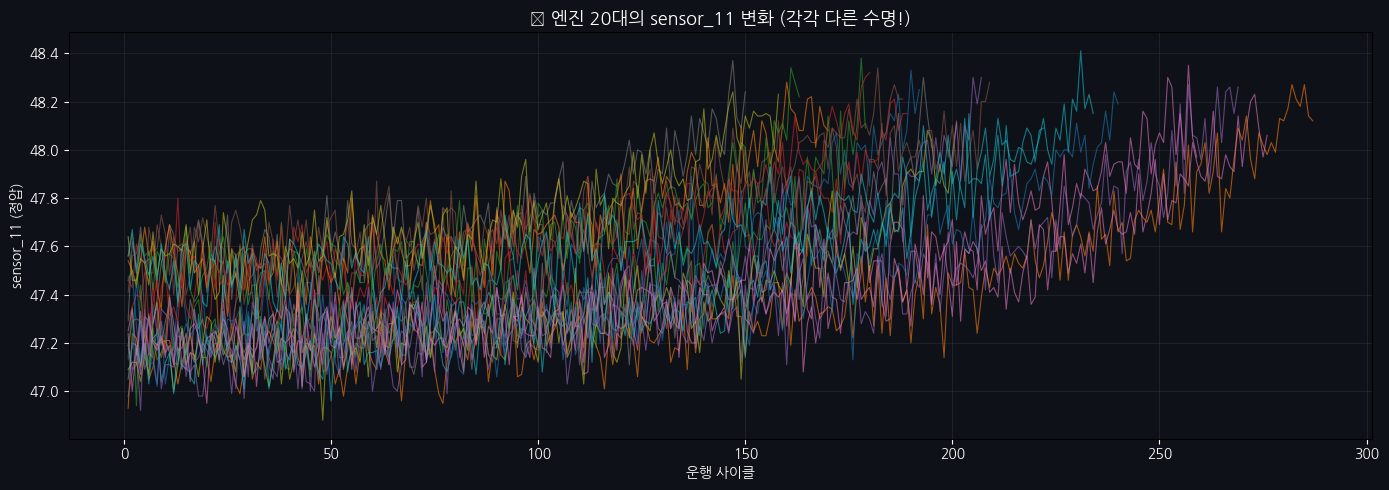

💡 같은 종류의 엔진이지만 수명이 제각각입니다!
   → 이래서 AI 기반 개별 예측이 필요합니다.


In [12]:
# 여러 엔진 수명 비교

fig, ax = plt.subplots(figsize=(14, 5))

for eid in range(1, 21):  # 20대 엔진
    eng = train_df[train_df['engine_id'] == eid]
    ax.plot(eng['cycle'], eng['sensor_11'], alpha=0.6, linewidth=0.8)

ax.set_title('📊 엔진 20대의 sensor_11 변화 (각각 다른 수명!)', fontsize=13, fontweight='bold')
ax.set_xlabel('운행 사이클')
ax.set_ylabel('sensor_11 (정압)')
ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

print("💡 같은 종류의 엔진이지만 수명이 제각각입니다!")
print("   → 이래서 AI 기반 개별 예측이 필요합니다.")

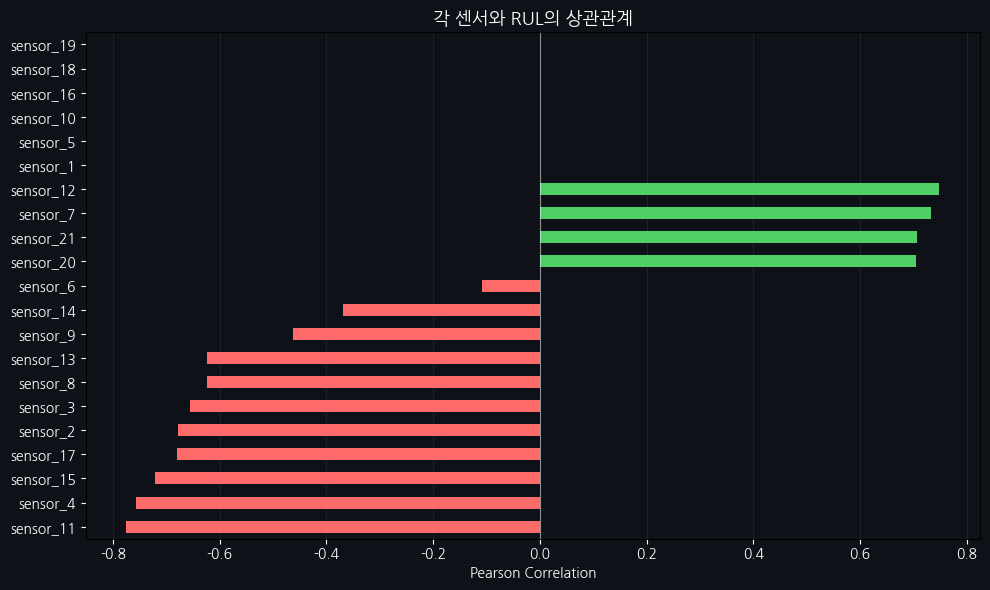


🎯 RUL과 상관관계 |r| > 0.3 인 센서: ['sensor_11', 'sensor_4', 'sensor_15', 'sensor_17', 'sensor_2', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_9', 'sensor_14', 'sensor_20', 'sensor_21', 'sensor_7', 'sensor_12']
   (14개 / 21개 센서 중)


In [14]:
# 센서 vs RUL 상관관계

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
correlations = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#ff6b6b' if v < 0 else '#51cf66' for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)

ax.set_title('각 센서와 RUL의 상관관계', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='white', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.1, axis='x')

plt.tight_layout()
plt.show()

# 유용한 센서 선별
useful_sensors = correlations[correlations.abs() > 0.3].index.tolist()
print(f"\n🎯 RUL과 상관관계 |r| > 0.3 인 센서: {useful_sensors}")
print(f"   ({len(useful_sensors)}개 / 21개 센서 중)")

---
## 3️⃣ 데이터 전처리

핵심 포인트:
- 변화가 거의 없는 센서는 제거 (분산 ≈ 0)
- **Train에서만 fit, Test에는 transform만** (Data Leakage 방지!)
- Sliding Window로 시퀀스 생성

In [15]:
# 분산이 거의 없는 센서 제거 (정보량 없음)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_cols = [f'op_setting_{i}' for i in range(1, 4)]

low_var = train_df[sensor_cols].std()
drop_sensors = low_var[low_var < 0.01].index.tolist()

print(f"🗑️ 제거할 센서 (분산 ≈ 0): {drop_sensors}")

feature_cols = [c for c in sensor_cols if c not in drop_sensors]
print(f"✅ 사용할 센서: {len(feature_cols)}개")

🗑️ 제거할 센서 (분산 ≈ 0): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
✅ 사용할 센서: 14개


In [16]:
# ⚠️ 정규화 — Train에서만 fit!

scaler = MinMaxScaler()

# Train fit + transform
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

# Test transform만
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print("✅ 정규화 완료 (Data Leakage 없음!)")
print(f"   Train: fit_transform | Test: transform only")

✅ 정규화 완료 (Data Leakage 없음!)
   Train: fit_transform | Test: transform only


In [17]:
# Sliding Window 생성

WINDOW_SIZE = 30  # 최근 30 사이클을 보고 RUL 예측

def create_sequences(df, feature_cols, window_size, is_test=False, rul_df=None):
    """엔진별로 sliding window 시퀀스 생성"""
    X, y = [], []

    for eid in df['engine_id'].unique():
        engine = df[df['engine_id'] == eid][feature_cols].values

        if is_test:
            # 테스트: 마지막 window만 사용
            if len(engine) >= window_size:
                X.append(engine[-window_size:])
                y.append(rul_df.iloc[eid - 1]['RUL'])
        else:
            # 학습: 모든 window 사용
            rul_values = df[df['engine_id'] == eid]['RUL'].values
            for i in range(len(engine) - window_size):
                X.append(engine[i:i + window_size])
                y.append(rul_values[i + window_size])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, feature_cols, WINDOW_SIZE)
X_test, y_test = create_sequences(test_df, feature_cols, WINDOW_SIZE, is_test=True, rul_df=rul_df)

# RUL cap 적용 (테스트에도 동일 기준)
y_test = np.clip(y_test, 0, RUL_CAP)

print(f"📐 학습 시퀀스: {X_train.shape}  (샘플, 윈도우, 센서)")
print(f"📐 테스트 시퀀스: {X_test.shape}")
print(f"📐 RUL 범위: 0 ~ {RUL_CAP} 사이클")

📐 학습 시퀀스: (17631, 30, 14)  (샘플, 윈도우, 센서)
📐 테스트 시퀀스: (100, 30, 14)
📐 RUL 범위: 0 ~ 125 사이클


---
## 4️⃣ 전통 ML 모델 학습

ML 모델은 3D 데이터를 못 받으므로 Flatten 필요!

In [18]:
# Flatten for ML

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"📐 Flatten 후: {X_train_flat.shape}")
print(f"   = {WINDOW_SIZE}시점 × {len(feature_cols)}센서 = {WINDOW_SIZE * len(feature_cols)} features")

📐 Flatten 후: (17631, 420)
   = 30시점 × 14센서 = 420 features


![랜덤포레스트](https://www.nvidia.com/content/dam/en-zz/Solutions/glossary/data-science/random-forest/img-3.png)

![랜덤포레스트설명2](https://velog.velcdn.com/images/gongsam/post/3a842926-2919-4983-8631-65b404ed65fc/image.png)

In [20]:
%%time
print("🌲 RandomForest 학습 중...")

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    warm_start=True
)

for n_trees in range(10, 51, 10):
    rf_model.n_estimators = n_trees
    rf_model.fit(X_train_flat, y_train)
    pred = rf_model.predict(X_test_flat)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"  Trees: {n_trees:3d}/50 | Test RMSE: {rmse:.2f}")

rf_pred = rf_model.predict(X_test_flat)
print("✅ RandomForest 완료!")

🌲 RandomForest 학습 중...
  Trees:  10/50 | Test RMSE: 16.68
  Trees:  20/50 | Test RMSE: 16.25
  Trees:  30/50 | Test RMSE: 16.31
  Trees:  40/50 | Test RMSE: 16.08
  Trees:  50/50 | Test RMSE: 16.02
✅ RandomForest 완료!
CPU times: user 5min 31s, sys: 775 ms, total: 5min 32s
Wall time: 3min 22s


![xgboost](https://www.researchgate.net/profile/Burak-Oeztornaci/publication/381857634/figure/fig5/AS:11431281257626830@1719839742918/Simplified-structure-of-XGBoost.ppm)

In [21]:
%%time
print("🚀 XGBoost 학습 중...")

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    warm_start=True
)

for n_rounds in range(20, 101, 20):
    xgb_model.n_estimators = n_rounds
    xgb_model.fit(X_train_flat, y_train)
    pred = xgb_model.predict(X_test_flat)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"  Rounds: {n_rounds:3d}/100 | Test RMSE: {rmse:.2f}")

xgb_pred = xgb_model.predict(X_test_flat)
print("✅ XGBoost 완료!")

🚀 XGBoost 학습 중...
  Rounds:  20/100 | Test RMSE: 21.33
  Rounds:  40/100 | Test RMSE: 16.39
  Rounds:  60/100 | Test RMSE: 15.31
  Rounds:  80/100 | Test RMSE: 14.93
  Rounds: 100/100 | Test RMSE: 14.53
✅ XGBoost 완료!
CPU times: user 1min 20s, sys: 444 ms, total: 1min 20s
Wall time: 50 s


---
## 5️⃣ 딥러닝 모델 학습 (RNN / LSTM)

시계열의 **순서 정보**를 직접 활용할 수 있는 모델!

In [23]:
# PyTorch DataLoader 준비

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).view(-1, 1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"✅ DataLoader 준비 완료 (batch_size=256, {len(train_loader)} batches)")

✅ DataLoader 준비 완료 (batch_size=256, 69 batches)


In [24]:
# 모델 정의 (개선된 버전)

class RULPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, model_type='LSTM', dropout=0.3):
        super().__init__()
        self.model_type = model_type

        rnn_class = nn.LSTM if model_type == 'LSTM' else nn.RNN
        self.rnn = rnn_class(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.head(out[:, -1, :])  # 마지막 시점의 hidden state
        return out

n_features = X_train.shape[2]
print(f"📐 입력 특성 수: {n_features}")
print(f"📐 모델 구조: {WINDOW_SIZE}시점 × {n_features}센서 → RUL 예측")

📐 입력 특성 수: 14
📐 모델 구조: 30시점 × 14센서 → RUL 예측


In [25]:
# 학습 함수

def train_model(model, train_loader, X_test_t, y_test, epochs=50, lr=0.001):
    """모델 학습 + 매 에폭 Test RMSE 기록"""

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'test_rmse': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch_X, batch_y in train_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)

        # Test 평가
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t).cpu().numpy().flatten()
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

        history['train_loss'].append(avg_loss)
        history['test_rmse'].append(test_rmse)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Test RMSE: {test_rmse:.2f}")

    # 최종 예측
    model.eval()
    with torch.no_grad():
        final_pred = model(X_test_t).cpu().numpy().flatten()

    return final_pred, history

![rnn,lstm](https://i.imgur.com/jKodJ1u.png)

In [26]:
%%time
# 🧠 RNN 학습

print("🧠 RNN 학습 시작!")
rnn_model = RULPredictor(n_features, hidden_size=64, num_layers=2, model_type='RNN').to(DEVICE)
rnn_pred, rnn_history = train_model(rnn_model, train_loader, X_test_t, y_test, epochs=50)
print("✅ RNN 완료!")

🧠 RNN 학습 시작!
  Epoch  10/50 | Loss: 4677.0689 | Test RMSE: 48.24
  Epoch  20/50 | Loss: 1041.3044 | Test RMSE: 22.21
  Epoch  30/50 | Loss: 903.6381 | Test RMSE: 15.86
  Epoch  40/50 | Loss: 861.1202 | Test RMSE: 14.66
  Epoch  50/50 | Loss: 840.9164 | Test RMSE: 13.98
✅ RNN 완료!
CPU times: user 20.6 s, sys: 709 ms, total: 21.3 s
Wall time: 22.8 s


In [27]:
%%time
# 🧠 LSTM 학습

print("🧠 LSTM 학습 시작!")
lstm_model = RULPredictor(n_features, hidden_size=64, num_layers=2, model_type='LSTM').to(DEVICE)
lstm_pred, lstm_history = train_model(lstm_model, train_loader, X_test_t, y_test, epochs=50)
print("✅ LSTM 완료!")

🧠 LSTM 학습 시작!
  Epoch  10/50 | Loss: 908.2007 | Test RMSE: 23.96
  Epoch  20/50 | Loss: 444.6637 | Test RMSE: 12.92
  Epoch  30/50 | Loss: 398.4225 | Test RMSE: 14.31
  Epoch  40/50 | Loss: 378.5083 | Test RMSE: 13.14
  Epoch  50/50 | Loss: 360.1574 | Test RMSE: 13.05
✅ LSTM 완료!
CPU times: user 18 s, sys: 146 ms, total: 18.2 s
Wall time: 18.4 s


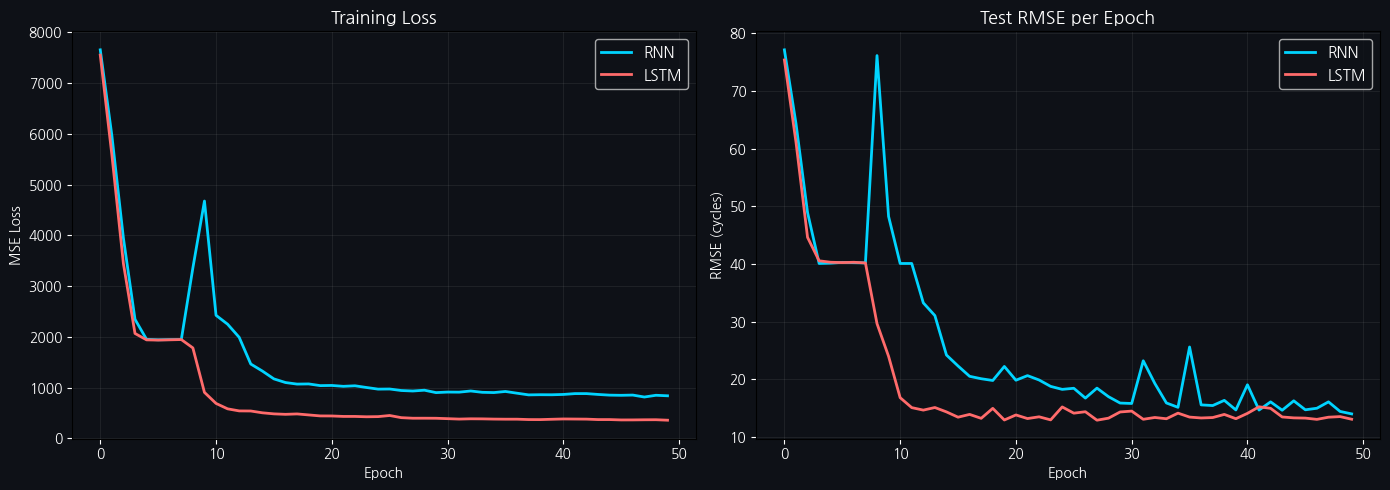

In [28]:
# 학습 곡선 비교

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
axes[0].plot(rnn_history['train_loss'], label='RNN', color='#00d4ff', linewidth=2)
axes[0].plot(lstm_history['train_loss'], label='LSTM', color='#ff6b6b', linewidth=2)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.1)

# Test RMSE
axes[1].plot(rnn_history['test_rmse'], label='RNN', color='#00d4ff', linewidth=2)
axes[1].plot(lstm_history['test_rmse'], label='LSTM', color='#ff6b6b', linewidth=2)
axes[1].set_title('Test RMSE per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (cycles)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

---
## 6️⃣ 모델 비교 평가

4개 모델을 RMSE, MAE, R² 세 가지 지표로 종합 비교!

In [29]:
# 종합 성능 비교

model_names = ['RandomForest', 'XGBoost', 'RNN', 'LSTM']
predictions = [rf_pred, xgb_pred, rnn_pred, lstm_pred]

results = []
for name, pred in zip(model_names, predictions):
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAE': mean_absolute_error(y_test, pred),
        'R²': r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('RMSE')

print("🏆 성능 랭킹")
print("=" * 55)
for i, row in results_df.iterrows():
    medal = ['🥇', '🥈', '🥉', '4️⃣'][list(results_df.index).index(i)]
    print(f"{medal} {row['Model']:15s} | RMSE: {row['RMSE']:6.2f} | MAE: {row['MAE']:6.2f} | R²: {row['R²']:.4f}")
print("=" * 55)
print(f"\n👑 최고 성능: {results_df.iloc[0]['Model']}")

🏆 성능 랭킹
🥇 LSTM            | RMSE:  13.05 | MAE:   9.76 | R²: 0.8940
🥈 RNN             | RMSE:  13.98 | MAE:  10.26 | R²: 0.8784
🥉 XGBoost         | RMSE:  14.53 | MAE:  10.88 | R²: 0.8685
4️⃣ RandomForest    | RMSE:  16.02 | MAE:  11.97 | R²: 0.8403

👑 최고 성능: LSTM


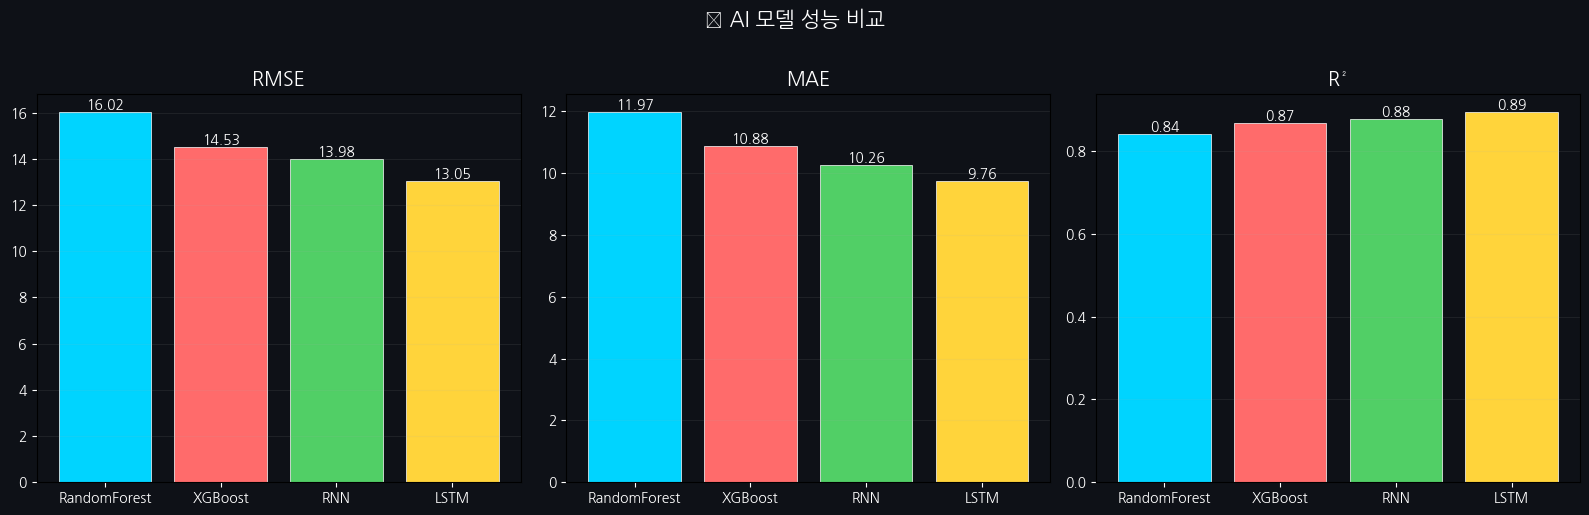

In [30]:
# 성능 비교 차트

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_colors = ['#00d4ff', '#ff6b6b', '#51cf66', '#ffd43b']
metrics = ['RMSE', 'MAE', 'R²']

for i, metric in enumerate(metrics):
    values = [r[metric] for r in results]
    bars = axes[i].bar(model_names, values, color=bar_colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].grid(True, alpha=0.1, axis='y')

    # 값 표시
    for bar, v in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{v:.2f}', ha='center', va='bottom', fontsize=10, color='white')

plt.suptitle('🏆 AI 모델 성능 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

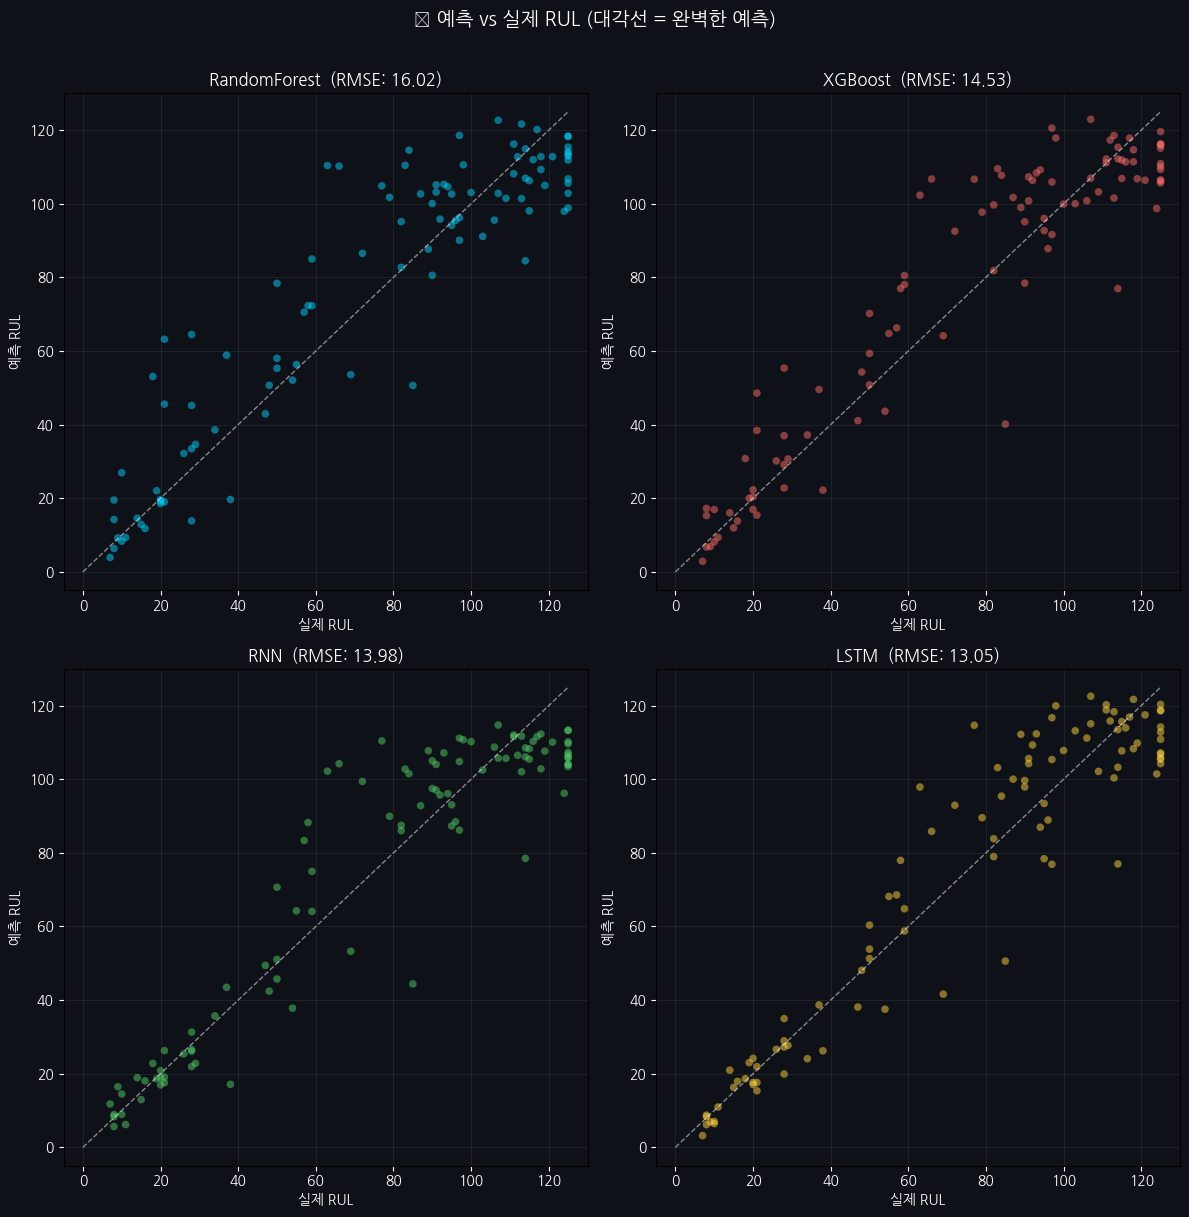

💡 점들이 대각선에 가까울수록 좋은 모델!


In [31]:
# 예측 vs 실제 산점도

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

colors_scatter = ['#00d4ff', '#ff6b6b', '#51cf66', '#ffd43b']

for i, (name, pred) in enumerate(zip(model_names, predictions)):
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    axes[i].scatter(y_test, pred, alpha=0.5, s=30, color=colors_scatter[i], edgecolor='none')
    axes[i].plot([0, RUL_CAP], [0, RUL_CAP], 'w--', alpha=0.5, linewidth=1)  # 완벽 예측선

    axes[i].set_title(f'{name}  (RMSE: {rmse:.2f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('실제 RUL')
    axes[i].set_ylabel('예측 RUL')
    axes[i].set_xlim(-5, RUL_CAP + 5)
    axes[i].set_ylim(-5, RUL_CAP + 5)
    axes[i].grid(True, alpha=0.1)

plt.suptitle('🎯 예측 vs 실제 RUL (대각선 = 완벽한 예측)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 점들이 대각선에 가까울수록 좋은 모델!")

---
## 7️⃣ 🚨 실전 시나리오: 이 엔진, 지금 교체해야 할까?

가장 좋은 모델을 골라서 **정비 의사결정 시스템**을 만들어봅시다!

In [32]:
# 최고 모델로 정비 의사결정

best_idx = results_df.index[0]
best_name = results_df.iloc[0]['Model']
best_pred = predictions[model_names.index(best_name)]

print(f"🏆 사용 모델: {best_name}\n")

# 정비 기준
DANGER_THRESHOLD = 15    # 15 사이클 이내 → 즉시 교체
WARNING_THRESHOLD = 40   # 40 사이클 이내 → 점검 필요

# 엔진별 상태 판단
status_df = pd.DataFrame({
    'engine_id': range(1, len(best_pred) + 1),
    'predicted_RUL': best_pred.round(1),
    'actual_RUL': y_test
})

def get_status(rul):
    if rul <= DANGER_THRESHOLD:
        return '🔴 즉시 교체'
    elif rul <= WARNING_THRESHOLD:
        return '🟡 점검 필요'
    else:
        return '🟢 정상 운행'

status_df['AI_판정'] = status_df['predicted_RUL'].apply(get_status)
status_df['실제_상태'] = status_df['actual_RUL'].apply(get_status)

# 결과 요약
print("📋 엔진 상태 리포트 (상위 20대)")
print("=" * 70)
for _, row in status_df.head(20).iterrows():
    match = '✅' if row['AI_판정'] == row['실제_상태'] else '❌'
    print(f"  엔진 #{row['engine_id']:3.0f} | "
          f"예측 RUL: {row['predicted_RUL']:6.1f} | "
          f"실제: {row['actual_RUL']:4.0f} | "
          f"{row['AI_판정']} {match}")

print("\n📊 AI 판정 분포:")
print(status_df['AI_판정'].value_counts().to_string())

# 위험 판정 정확도
correct = (status_df['AI_판정'] == status_df['실제_상태']).sum()
total = len(status_df)
print(f"\n🎯 상태 판정 일치율: {correct}/{total} ({correct/total*100:.1f}%)")

🏆 사용 모델: LSTM

📋 엔진 상태 리포트 (상위 20대)
  엔진 #  1 | 예측 RUL:  115.8 | 실제:  112 | 🟢 정상 운행 ✅
  엔진 #  2 | 예측 RUL:  120.0 | 실제:   98 | 🟢 정상 운행 ✅
  엔진 #  3 | 예측 RUL:   41.6 | 실제:   69 | 🟢 정상 운행 ✅
  엔진 #  4 | 예측 RUL:   79.0 | 실제:   82 | 🟢 정상 운행 ✅
  엔진 #  5 | 예측 RUL:  105.6 | 실제:   91 | 🟢 정상 운행 ✅
  엔진 #  6 | 예측 RUL:  112.3 | 실제:   93 | 🟢 정상 운행 ✅
  엔진 #  7 | 예측 RUL:  104.3 | 실제:   91 | 🟢 정상 운행 ✅
  엔진 #  8 | 예측 RUL:   93.4 | 실제:   95 | 🟢 정상 운행 ✅
  엔진 #  9 | 예측 RUL:  118.8 | 실제:  111 | 🟢 정상 운행 ✅
  엔진 # 10 | 예측 RUL:   88.9 | 실제:   96 | 🟢 정상 운행 ✅
  엔진 # 11 | 예측 RUL:   76.9 | 실제:   97 | 🟢 정상 운행 ✅
  엔진 # 12 | 예측 RUL:  101.4 | 실제:  124 | 🟢 정상 운행 ✅
  엔진 # 13 | 예측 RUL:   78.4 | 실제:   95 | 🟢 정상 운행 ✅
  엔진 # 14 | 예측 RUL:  115.1 | 실제:  107 | 🟢 정상 운행 ✅
  엔진 # 15 | 예측 RUL:  103.2 | 실제:   83 | 🟢 정상 운행 ✅
  엔진 # 16 | 예측 RUL:   95.4 | 실제:   84 | 🟢 정상 운행 ✅
  엔진 # 17 | 예측 RUL:   51.3 | 실제:   50 | 🟢 정상 운행 ✅
  엔진 # 18 | 예측 RUL:   27.2 | 실제:   28 | 🟡 점검 필요 ✅
  엔진 # 19 | 예측 RUL:  100.0 | 실제:   87 | 🟢 정상 운행 ✅
  엔진 # 20 | 예측

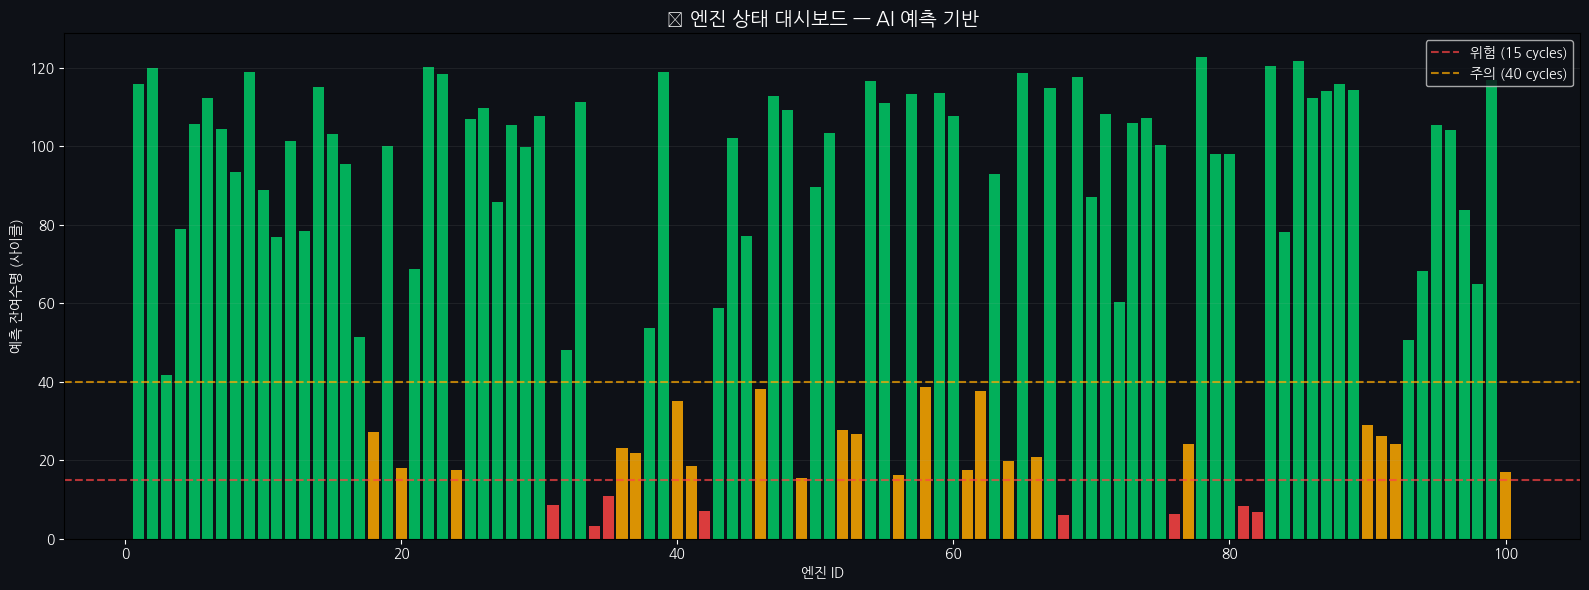


🚨 즉시 정비 필요 엔진: 8대
   → 이 엔진들을 방치하면 비행 중 고장 위험!


In [33]:
# 엔진 상태 대시보드

fig, ax = plt.subplots(figsize=(16, 6))

engine_ids = status_df['engine_id'].values
pred_rul = status_df['predicted_RUL'].values

bar_colors = []
for r in pred_rul:
    if r <= DANGER_THRESHOLD:
        bar_colors.append('#ff4444')
    elif r <= WARNING_THRESHOLD:
        bar_colors.append('#ffaa00')
    else:
        bar_colors.append('#00cc66')

ax.bar(engine_ids, pred_rul, color=bar_colors, edgecolor='none', alpha=0.85)

# 기준선
ax.axhline(y=DANGER_THRESHOLD, color='#ff4444', linestyle='--', alpha=0.7, label=f'위험 ({DANGER_THRESHOLD} cycles)')
ax.axhline(y=WARNING_THRESHOLD, color='#ffaa00', linestyle='--', alpha=0.7, label=f'주의 ({WARNING_THRESHOLD} cycles)')

ax.set_title('🏭 엔진 상태 대시보드 — AI 예측 기반', fontsize=14, fontweight='bold')
ax.set_xlabel('엔진 ID')
ax.set_ylabel('예측 잔여수명 (사이클)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.1, axis='y')

plt.tight_layout()
plt.show()

danger_count = sum(1 for r in pred_rul if r <= DANGER_THRESHOLD)
print(f"\n🚨 즉시 정비 필요 엔진: {danger_count}대")
print(f"   → 이 엔진들을 방치하면 비행 중 고장 위험!")

---
## 📝 실습 정리

### 오늘 배운 것

| 항목 | 내용 |
|------|------|
| **데이터** | NASA C-MAPSS 터보팬 엔진 실제 시뮬레이션 데이터 |
| **문제** | 센서 시계열 → 잔여수명(RUL) 회귀 예측 |
| **전처리** | Data Leakage 방지, 분산 필터링, Sliding Window |
| **ML 모델** | RandomForest, XGBoost (Flatten 입력) |
| **DL 모델** | RNN, LSTM (시퀀스 입력, Dropout, LR Scheduler) |
| **평가** | RMSE, MAE, R² 다중 지표 |
| **응용** | 정비 의사결정 시스템 (위험/주의/정상 분류) |

### 🤔 토론 주제
1. Window Size를 바꾸면 성능이 어떻게 변할까?
2. 위험 기준(threshold)을 바꾸면 실제 정비 비용에 어떤 영향이 있을까?